In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install wordcloud
from wordcloud import WordCloud, STOPWORDS
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.figure_factory as ff
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier
import re
import warnings
warnings.filterwarnings('ignore')
# NLTK imports
import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from collections import Counter, defaultdict
import string
from datetime import datetime
import joblib
import os
from nltk.probability import FreqDist

try:
    nltk.data.find('tokenizers/punkt')
    nltk.data.find('vader_lexicon')
except LookupError:
    nltk.download('punkt')
    nltk.download('vader_lexicon')
    nltk.download('stopwords')
    import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\navya_h6k3hwg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\navya_h6k3hwg\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\navya_h6k3hwg\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\navya_h6k3hwg\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [2]:
!pip install datasets

In [3]:
!pip install datasets huggingface_hub pyarrow fsspec

In [4]:
from datasets import load_dataset
ds = load_dataset("drorrabin/phishing_emails-data")
print(ds)

Repo card metadata block was not found. Setting CardData to empty.


DatasetDict({
    train: Dataset({
        features: ['text', 'email_type'],
        num_rows: 26946
    })
    test: Dataset({
        features: ['text', 'email_type'],
        num_rows: 3705
    })
})


In [5]:
train_data = ds['train']

In [6]:
train_df = train_data.to_pandas()

In [7]:
print(train_df.head())

                                                text      email_type
0  Is the following email safe or phishing??\n\nD...  phishing email
1  Is the following email safe or phishing??\n\nD...  phishing email
2  Is the following email safe or phishing??\n\nD...      safe email
3  Is the following email safe or phishing??\n\nD...  phishing email
4  Is the following email safe or phishing??\n\nD...  phishing email


In [8]:
print(train_df['email_type'].unique())

['phishing email' 'safe email']


In [9]:
train_df['email_type'] = (
    train_df['email_type']
    .str.strip()
    .str.lower()
)

In [10]:
train_df = train_data.to_pandas()

train_df.head()  # Check Dataset
train_df.info()
train_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26946 entries, 0 to 26945
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        26946 non-null  object
 1   email_type  26946 non-null  object
dtypes: object(2)
memory usage: 421.2+ KB


(26946, 2)

In [11]:
# Check missing values
print(train_df.isnull().sum())

# Check dataset shape before removing
print("Before removing missing values:", train_df.shape)

# Remove missing values
train_df.dropna(inplace=True)

# Check dataset shape after removing
print("After removing missing values:", train_df.shape)

# Verify again
print(train_df.isnull().sum())

text          0
email_type    0
dtype: int64
Before removing missing values: (26946, 2)
After removing missing values: (26946, 2)
text          0
email_type    0
dtype: int64


In [12]:
# Check duplicates
print("Duplicate rows:", train_df.duplicated().sum())

# Dataset shape before removing duplicates
print("Before:", train_df.shape)

# Remove duplicates
train_df.drop_duplicates(inplace=True)

# Dataset shape after removing duplicates
print("After:", train_df.shape)

# Verify duplicates removed
print("Duplicate rows after cleaning:", train_df.duplicated().sum())

Duplicate rows: 0
Before: (26946, 2)
After: (26946, 2)
Duplicate rows after cleaning: 0


In [13]:
train_df.shape

(26946, 2)

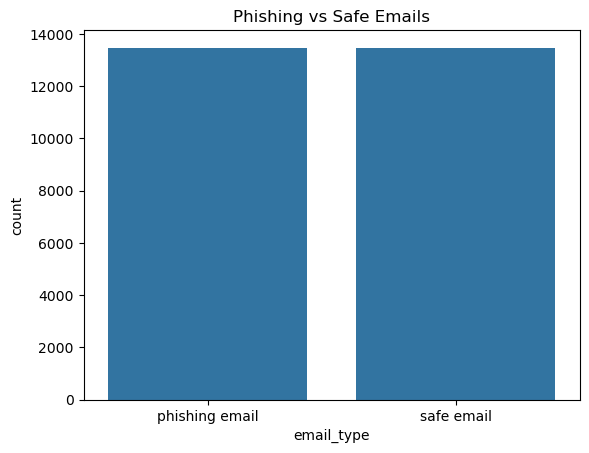

In [14]:
sns.countplot(
    x='email_type',
    data=train_df
)

plt.title("Phishing vs Safe Emails")
plt.show()

In [15]:
print(train_df['email_type'].head())

0    phishing email
1    phishing email
2        safe email
3    phishing email
4    phishing email
Name: email_type, dtype: object


In [16]:
train_df['email_length'] = train_df['text'].apply(len)

In [17]:
train_df['email_length'].describe()

count    26946.000000
mean       752.172790
std        248.698131
min        251.000000
25%        534.000000
50%        816.000000
75%        948.000000
max       1820.000000
Name: email_length, dtype: float64

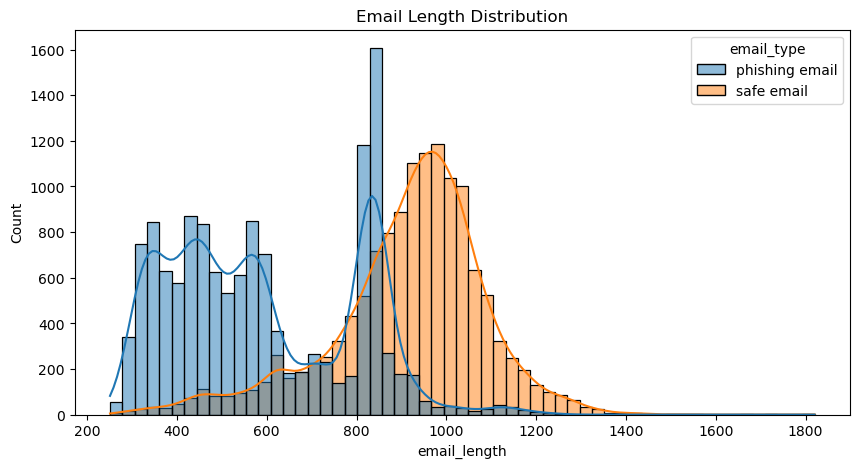

In [18]:
#Email Length Analysis
plt.figure(figsize=(10,5))

sns.histplot(
    data=train_df,
    x='email_length',
    hue='email_type',
    kde=True
)

plt.title("Email Length Distribution")

plt.show()

In [19]:
#Word Count Analysis
train_df['word_count'] = train_df['text'].apply(
    lambda x: len(str(x).split())
)

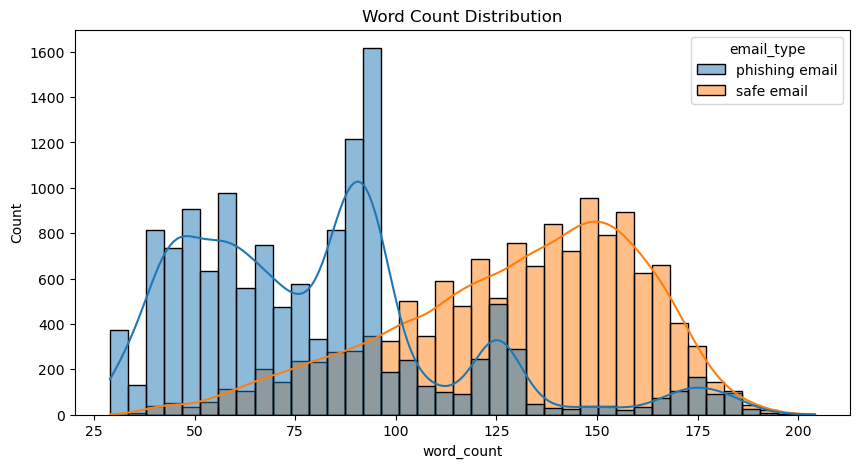

In [20]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=train_df,
    x='word_count',
    hue='email_type',
    kde=True
)

plt.title("Word Count Distribution")
plt.show()

In [24]:
#Text Preprocessing

# Create stopword list
stop_words = set(stopwords.words('english'))

# Text preprocessing function
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r'http\S+',
        '',
        text
    )

    # Remove numbers
    text = re.sub(
        r'\d+',
        '',
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

# Apply preprocessing
train_df['clean_email'] = train_df['text'].apply(
    preprocess_text
)

In [26]:
train_df['clean_email'] = train_df['clean_email'].apply(
    lambda x: " ".join([
        word for word in x.lower().split()
        if word.strip() not in stop_words
        and len(word) > 2
    ])
)

In [28]:
print(type(stop_words))

<class 'set'>


In [29]:
stop_words = set([
    'following',
    'safe',
    'phishing',
    'email',
    'type',
    'subject',
    'body',
    'sender',
    'receiver',
    'date',
    'cnn',
    'usergvcceaschallengecc',

    'mon','monday','tue','tuesday',
    'wed','wednesday','thu','thursday',
    'fri','friday','sat','saturday',
    'sun','sunday',

    'jan','feb','mar','apr','may',
    'jun','jul','aug','sep',
    'oct','nov','dec'
])

train_df['clean_email'] = train_df['clean_email'].apply(
    lambda x: " ".join([
        word for word in x.lower().split()
        if word.strip() not in stop_words
        and len(word) > 2
    ])
)

In [30]:
# word frequency

phish_words = " ".join(
    train_df[
        train_df['email_type'] == 'phishing email'
    ]['clean_email']
)

safe_words = " ".join(
    train_df[
        train_df['email_type'] == 'safe email'
    ]['clean_email']
)

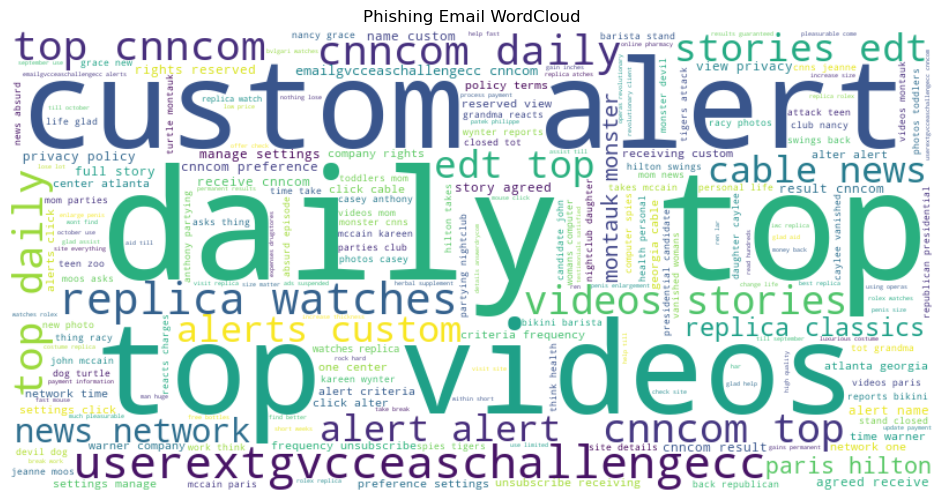

In [31]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(phish_words)

plt.figure(figsize=(12,6))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)
plt.axis('off')
plt.title("Phishing Email WordCloud")
plt.show()

                         Word  Frequency
0                         top       9642
1                       daily       5521
2                      cnncom       5389
3                     replica       4808
4                       alert       4329
5                      videos       3704
6                     watches       3505
7                      custom       3478
8                      alerts       3471
9   userextgvcceaschallengecc       3297
10                       news       2491
11                      click       2348
12                       time       2000
13                        edt       1833
14                    stories       1831
15                    network       1754
16                   settings       1733
17                      cable       1730
18                       life       1656
19                        one       1654


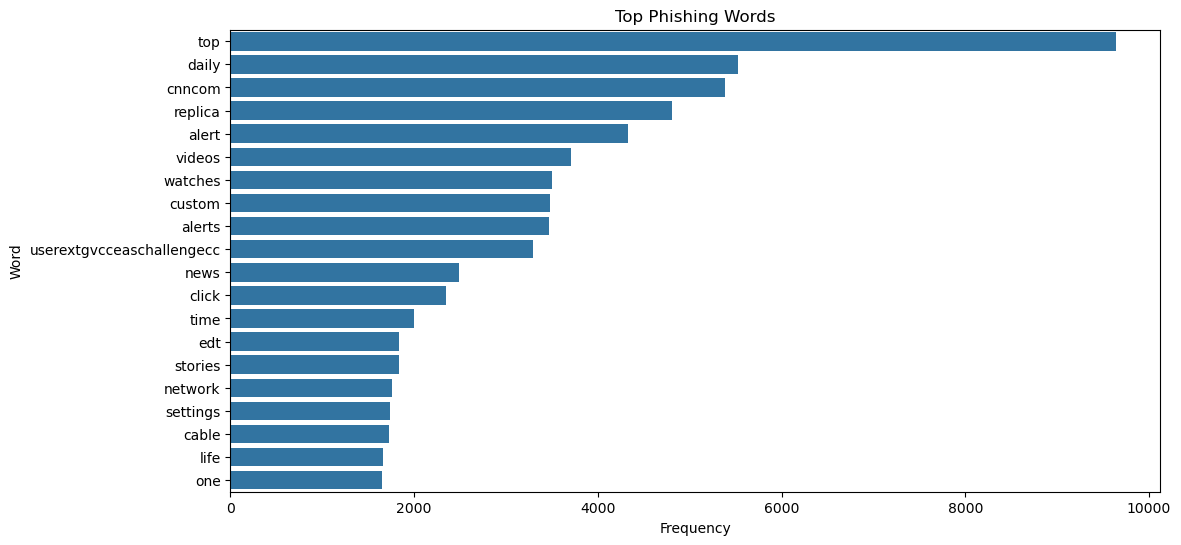

In [32]:
# Tokenize phishing words

tokens = word_tokenize(
    phish_words
)

# Frequency distribution

freq = FreqDist(
    tokens
)

# Create dataframe

freq_df = pd.DataFrame(
    freq.most_common(20),
    columns=['Word', 'Frequency']
)

# Display dataframe

print(freq_df)

# Visualization

plt.figure(figsize=(12,6))

sns.barplot(
    data=freq_df,
    x='Frequency',
    y='Word'
)

plt.title("Top Phishing Words")

plt.show()

In [33]:
#Lexical Feature Engineering
train_df['uppercase_ratio'] = train_df['text'].apply(
    lambda x: sum(
        1 for c in str(x)
        if c.isupper()
    ) / len(str(x))
)

In [34]:
train_df['numeric_ratio'] = train_df['text'].apply(
    lambda x: sum(
        1 for c in str(x)
        if c.isdigit()
    ) / len(str(x))
)

In [35]:
special_chars = "!@#$%^&*()"

train_df['special_ratio'] = train_df['text'].apply(
    lambda x: sum(
        1 for c in str(x)
        if c in special_chars
    ) / len(str(x))
)

In [36]:
#URL Analysis
train_df['url_count'] = train_df['text'].apply(
    lambda x: len(
        re.findall(
            r'http[s]?://\S+',
            str(x)
        )
    )
)

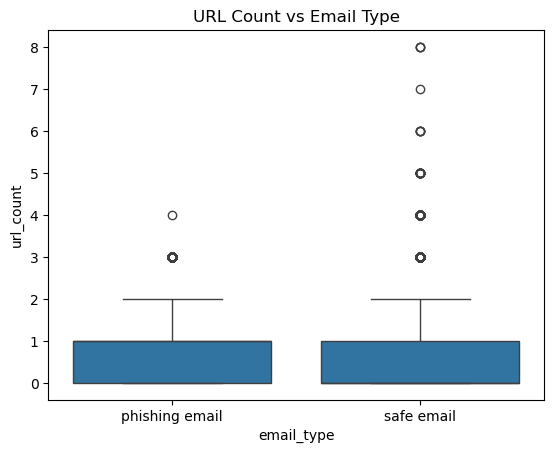

In [37]:
sns.boxplot(
    x='email_type',
    y='url_count',
    data=train_df
)

plt.title("URL Count vs Email Type")

plt.show()

In [38]:
# Count stopwords from original emails

stop_words = set(
    stopwords.words('english')
)

total_stopwords = 0

phishing_stopwords = 0

safe_stopwords = 0

for index, row in train_df.iterrows():

    words = str(
        row['text']
    ).lower().split()

    count = sum(
        1 for word in words
        if word in stop_words
    )

    total_stopwords += count

    if row['email_type'] == 1:

        phishing_stopwords += count

    else:

        safe_stopwords += count

print("Total Stopwords:", total_stopwords)

print("Phishing Stopwords:", phishing_stopwords)

print("Safe Stopwords:", safe_stopwords)

Total Stopwords: 773463
Phishing Stopwords: 0
Safe Stopwords: 773463


In [39]:
print("Original Email:\n")

print(train_data[0])

print("\nCleaned Email:\n")

print(
    train_df['clean_email'].iloc[0]
)

Original Email:

{'text': 'Is the following email safe or phishing??\n\nDate: Thu, 07 Aug 2008 10:59:35 +0200\n\nSender: Daily Top 10 <avadivap_1981@techsult.com>\n\nReceiver: user2.12@gvc.ceas-challenge.cc\n\nEmail Subject: CNN.com Daily Top 10\n\nEmail Body: THE DAILY TOP 10 from CNN.com Top videos and stories as of: Aug  1, 2008  3:58 PM EDT  TOP 10 VIDEOS 1. PARIS HILTON TAKES ON MCCAIN http://www.cnn.com/video/partners/email/index.html?url/video/politics/2008/08/06/wynter.paris.hilton.ad.cnn Paris Hilton swings back at Republican presidential candidate John McCain. Kareen Wynter reports. 2. BIKINI BARISTA STAND CLOSED http://www.cnn.com/video/partners/email/index.html?url/video/living/2008/08/06/pkg.bikini.baristas.barred.kiro 3. TOT GRANDMA REACTS TO CHARGES http://www.cnn.com/video/partners/email/index.html?url/video/crime/2008/08\n\nEmail type is: phishing email', 'email_type': 'phishing email'}

Cleaned Email:

daily top avadivaptechsultcom cnncom daily top daily top cnncom to

In [40]:
X = train_df['clean_email']

In [41]:
y = train_df['email_type']

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
pipeline = Pipeline([

    (
        'tfidf',

        TfidfVectorizer(
            max_features=10000,
            ngram_range=(1,2),
            stop_words='english'
        )
    ),

    (
        'classifier',

        SGDClassifier(
            loss='hinge',
            random_state=42
        )
    )

])

In [46]:
print(X_train.shape)

print(X_test.shape)

(21556,)
(5390,)


In [47]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [48]:
X_train_tfidf = tfidf.fit_transform(X_train) 

In [49]:
X_test_tfidf = tfidf.transform(X_test)

In [50]:
print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(21556, 10000)
(5390, 10000)


In [51]:
print(X_train_tfidf)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 862685 stored elements and shape (21556, 10000)>
  Coords	Values
  (0, 4761)	0.11560977321604793
  (0, 5219)	0.1532620282620992
  (0, 4101)	0.1539051558638542
  (0, 2826)	0.21184049497068874
  (0, 9716)	0.15456215250972014
  (0, 172)	0.1774755061265721
  (0, 9418)	0.20213815277962924
  (0, 738)	0.15342154191877164
  (0, 5068)	0.11148661572585107
  (0, 5842)	0.12729999571940157
  (0, 5700)	0.223654562460275
  (0, 420)	0.22209180766852937
  (0, 5786)	0.223654562460275
  (0, 1578)	0.18525836586983382
  (0, 7613)	0.16010035169132847
  (0, 4986)	0.19877026920011798
  (0, 7243)	0.16226643389781253
  (0, 4633)	0.15883274004846842
  (0, 5771)	0.15247675183185602
  (0, 4934)	0.17215643112277187
  (0, 4942)	0.14174199959724268
  (0, 8206)	0.21184049497068874
  (0, 4153)	0.21850330734785128
  (0, 1099)	0.21238946547746987
  (0, 421)	0.23895181720740735
  :	:
  (21555, 205)	0.07852473238268329
  (21555, 1867)	0.07855037230849297
  (2155

In [52]:
print(tfidf.get_feature_names_out())

['aaai' 'aaai workshop' 'aahz' ... 'ラウフロック' 'ラウフロック ヴァン' 'ヴァン']


In [53]:
print(len(tfidf.get_feature_names_out()))

10000


In [54]:
print(X_train_tfidf[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 29 stored elements and shape (1, 10000)>
  Coords	Values
  (0, 4761)	0.11560977321604793
  (0, 5219)	0.1532620282620992
  (0, 4101)	0.1539051558638542
  (0, 2826)	0.21184049497068874
  (0, 9716)	0.15456215250972014
  (0, 172)	0.1774755061265721
  (0, 9418)	0.20213815277962924
  (0, 738)	0.15342154191877164
  (0, 5068)	0.11148661572585107
  (0, 5842)	0.12729999571940157
  (0, 5700)	0.223654562460275
  (0, 420)	0.22209180766852937
  (0, 5786)	0.223654562460275
  (0, 1578)	0.18525836586983382
  (0, 7613)	0.16010035169132847
  (0, 4986)	0.19877026920011798
  (0, 7243)	0.16226643389781253
  (0, 4633)	0.15883274004846842
  (0, 5771)	0.15247675183185602
  (0, 4934)	0.17215643112277187
  (0, 4942)	0.14174199959724268
  (0, 8206)	0.21184049497068874
  (0, 4153)	0.21850330734785128
  (0, 1099)	0.21238946547746987
  (0, 421)	0.23895181720740735
  (0, 5787)	0.23406665146170708
  (0, 1579)	0.23406665146170708
  (0, 5773)	0.18436221188715

In [55]:
print(X_train_tfidf[0].toarray())

[[0. 0. 0. ... 0. 0. 0.]]


In [56]:
svm_model = SVC(
    kernel='linear'
)

In [57]:
from sklearn.model_selection import (
    cross_val_score,
    StratifiedKFold
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    svm_model,
    X_train_tfidf,
    y_train,
    cv=cv,
    scoring='accuracy'
)

print(cv_scores)

print(
    "Average CV Accuracy:",
    cv_scores.mean()
)

[0.99304267 0.99512874 0.99512874 0.99396892 0.99489678]
Average CV Accuracy: 0.9944331689783523


In [61]:
svm_model.fit(
    X_train_tfidf,
    y_train
)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [63]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)
# Prediction
y_pred = svm_model.predict(X_test_tfidf)

# Precision
precision = precision_score(
    y_test,
    y_pred,
    pos_label='phishing email'
)

# Recall
recall = recall_score(
    y_test,
    y_pred,
    pos_label='phishing email'
)

# F1 Score
f1 = f1_score(
    y_test,
    y_pred,
    pos_label='phishing email'
)

# Print Results
print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

Precision: 0.9940784603997039
Recall: 0.9966604823747681
F1 Score: 0.9953677969242172


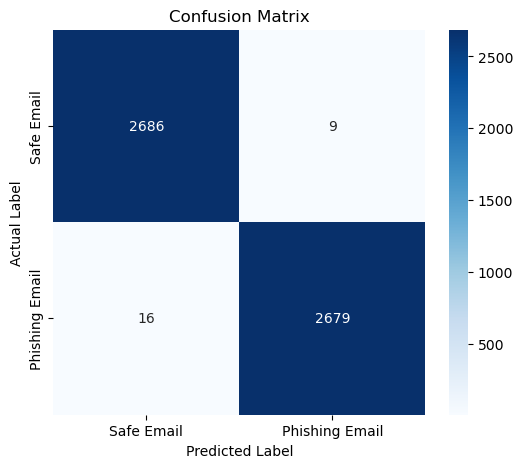

In [64]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Safe Email', 'Phishing Email'],
    yticklabels=['Safe Email', 'Phishing Email']
)

plt.xlabel("Predicted Label")

plt.ylabel("Actual Label")

plt.title("Confusion Matrix")

plt.show()

In [66]:
# Custom email
sample_email = """
Dear Employee,

As part of our annual security upgrade, all staff members are required to reconfirm their Microsoft Outlook credentials before midnight today.

Failure to complete verification may temporarily restrict access to email services.

Please use the secure employee portal below:

https://outlook-securityverify-support.com/login

Thank you for your cooperation.

IT Support Team
"""

# Preprocess email
cleaned_email = preprocess_text(sample_email)

# Convert into TF-IDF vector
email_vector = tfidf.transform([cleaned_email])

# Predict
prediction = svm_model.predict(email_vector)

# Show prediction
print("Prediction:", prediction[0])

# Convert prediction into readable text
if prediction[0] == 'phishing email':
    
    print("This is a Phishing Email")

else:
    
    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [ ]:
# Custom email
sample_email = """
Dear Customer,

Your bank account has been temporarily locked due to unusual activity.

Please verify your account immediately by clicking the link below:

http://secure-bank-verification.com

Failure to verify may result in account suspension.

Thank you,
Bank Security Team
"""

# Preprocess email
cleaned_email = preprocess_text(sample_email)

# Convert into TF-IDF vector
email_vector = tfidf.transform([cleaned_email])

# Predict
prediction = svm_model.predict(email_vector)

# Show prediction
print("Prediction:", prediction[0])

# Convert prediction into readable text
if prediction[0] == 'phishing email':
    
    print("This is a Phishing Email")

else:
    
    print("This is a Safe Email")

In [67]:
# Custom email
sample_email = """
Dear User,
Your Account is in danger 
All Hotmail customers have been upgraded to Outlook.com. Your Hotmail Account services has expired.

Due to our new system upgrade to Outlook. In order for it to remain active follow the link Sign in Re-activate your account to Outlook. https://account.live.com

Thanks,

The Microsoft account team
"""

# Preprocess email
cleaned_email = preprocess_text(sample_email)

# Convert into TF-IDF vector
email_vector = tfidf.transform([cleaned_email])

# Predict
prediction = svm_model.predict(email_vector)

# Show prediction
print("Prediction:", prediction[0])

# Convert prediction into readable text
if prediction[0] == 'phishing email':
    
    print("This is a Phishing Email")

else:
    
    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [68]:
from sklearn.linear_model import SGDClassifier
sgd_model = SGDClassifier(
    loss='hinge',
    random_state=42
)

In [69]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    sgd_model,
    X_train_tfidf,
    y_train,
    cv=5,
    scoring='accuracy'
)

In [70]:
print(cv_scores)

[0.99281076 0.99466481 0.99350499 0.99489678 0.99304106]


In [71]:
print(
    "Average CV Accuracy:",
    cv_scores.mean()
)

Average CV Accuracy: 0.9937836784615788


In [72]:
sgd_model.fit(
    X_train_tfidf,
    y_train
)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [73]:
y_pred_sgd = sgd_model.predict(
    X_test_tfidf
)

In [74]:
accuracy = accuracy_score(
    y_test,
    y_pred_sgd
)

print("Accuracy:", accuracy)

Accuracy: 0.9953617810760668


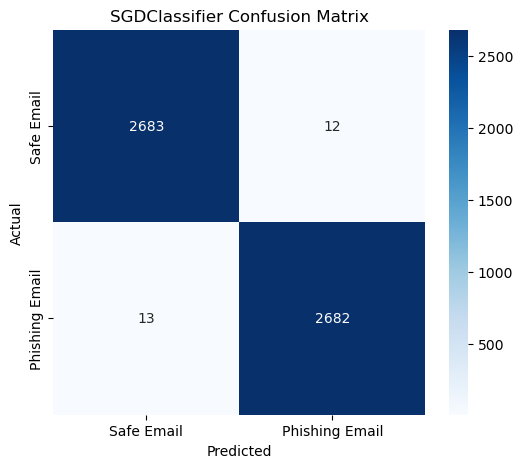

In [76]:
cm = confusion_matrix(
    y_test,
    y_pred_sgd
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Safe Email', 'Phishing Email'],
    yticklabels=['Safe Email', 'Phishing Email']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("SGDClassifier Confusion Matrix")
plt.show()

In [101]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

phishing email       0.99      1.00      1.00      2695
    safe email       1.00      0.99      1.00      2695

      accuracy                           1.00      5390
     macro avg       1.00      1.00      1.00      5390
  weighted avg       1.00      1.00      1.00      5390



In [79]:
# Custom email
sample_email = """
Hi

Thanks for working with us. Your bill for $373.75 was due on 28 Aug 2016.

If you've already paid it, please ignore this email and sorry for bothering you. If you've not paid it, please do so as soon as possible.

To view your bill visit https://in.xero.com/5LQDhRwfvoOfeDtl.DMqkk1JWSqC4CmJt4VVJRSGN

If you've got any questions, or want to arrange alternative payment don't hesitate to get in touch.

Thanks

NJW Limited
"""


# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)


# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)


# Predict
prediction = sgd_model.predict(
    email_vector
)


# Show prediction
print("Prediction:", prediction[0])


# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [80]:
# Feedback email
feedback_email = """
Hi

Thanks for working with us. Your bill for $373.75 was due on 28 Aug 2016.

If you've already paid it, please ignore this email and sorry for bothering you. If you've not paid it, please do so as soon as possible.

To view your bill visit https://in.xero.com/5LQDhRwfvoOfeDtl.DMqkk1JWSqC4CmJt4VVJRSGN

If you've got any questions, or want to arrange alternative payment don't hesitate to get in touch.

Thanks

NJW Limited
"""
# Correct label
feedback_label = ['phishing email']
# Preprocess email
cleaned_feedback = preprocess_text(
    feedback_email
)

# Convert into TF-IDF vector
feedback_vector = tfidf.transform(
    [cleaned_feedback]
)

# Continuous learning / feedback training
sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("Feedback training completed successfully.")

Feedback training completed successfully.


In [81]:
sample_email = """
Hi

Thanks for working with us. Your bill for $373.75 was due on 28 Aug 2016.

If you've already paid it, please ignore this email and sorry for bothering you. If you've not paid it, please do so as soon as possible.

To view your bill visit https://in.xero.com/5LQDhRwfvoOfeDtl.DMqkk1JWSqC4CmJt4VVJRSGN

If you've got any questions, or want to arrange alternative payment don't hesitate to get in touch.

Thanks

NJW Limited
"""


# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)


# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)
# Predict
prediction = sgd_model.predict(
    email_vector
)


# Show prediction
print("Prediction:", prediction[0])


# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [ ]:
sample_email ="""Dear Beloved Friend,

I know this message will come to you as surprised but permit me of my desire to go into business relationship with you.

I am Miss Naomi Surugaba a daughter to late Al-badari Surugaba of Libya whom was murdered during the recent civil war in Libya in March 2011, before his death my late father was a strong supporter and a member of late Moammar Gadhafi Government in Tripoli.

Meanwhile before the incident, my late Father came to Cotonou Benin republic with the sum of USD4, 200,000.00 (US$4.2M) which he deposited in a Bank here in Cotonou Benin Republic West Africa for safe keeping.

I am here seeking for an avenue to transfer the fund to you in only you're reliable and trustworthy person to Investment the fund. I am here in Benin Republic because of the death of my parent's and I want you to help me transfer the fund into your bank account for investment purpose.

Please I will offer you 20% of the total sum of USD4.2M for your assistance. Please I wish to transfer the fund urgently without delay into your account and also wish to relocate to your country due to the poor condition in Benin, as to enable me continue my education as I was a medical student before the sudden death of my parent's. Reply to my alternative email:missnaomisurugaba2@hotmail.com, Your immediate response would be appreciated.

Remain blessed, Miss Naomi Surugaba."""



In [82]:
sample_email = """Dear Employee,
Your Microsoft 365 password will expire today. Please confirm your credentials immediately to avoid interruption of email access:
http://microsoft-securityverify.com"""
# Correct label
feedback_label = ['phishing email']
# Preprocess email
cleaned_feedback = preprocess_text(
    feedback_email
)

# Convert into TF-IDF vector
feedback_vector = tfidf.transform(
    [cleaned_feedback]
)

# Continuous learning / feedback training
sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("Feedback training completed successfully.")

Feedback training completed successfully.


In [83]:
sample_email = """Dear Customer,
We noticed suspicious login activity on your PayPal account. Verify your identity within 24 hours to prevent account suspension:
http://paypal-account-check.com"""
# Correct label
feedback_label = ['phishing email']
# Preprocess email
cleaned_feedback = preprocess_text(
    feedback_email
)

# Convert into TF-IDF vector
feedback_vector = tfidf.transform(
    [cleaned_feedback]
)

# Continuous learning / feedback training
sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("Feedback training completed successfully.")

Feedback training completed successfully.


In [84]:
# Custom email
sample_email = """
Hi

Thanks for working with us. Your bill for $373.75 was due on 28 Aug 2016.

If you've already paid it, please ignore this email and sorry for bothering you. If you've not paid it, please do so as soon as possible.

To view your bill visit https://in.xero.com/5LQDhRwfvoOfeDtl.DMqkk1JWSqC4CmJt4VVJRSGN

If you've got any questions, or want to arrange alternative payment don't hesitate to get in touch.

Thanks

NJW Limited
"""


# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)


# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)


# Predict
prediction = sgd_model.predict(
    email_vector
)


# Show prediction
print("Prediction:", prediction[0])


# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [85]:
sample_email = """Subject: Updated Shared Document for Review

Hi Sudha,

I’ve attached the updated project document with the final changes discussed during yesterday’s meeting. Please review it before today’s deadline and let me know if anything else needs to be modified.

You can access the file securely using the link below:

https://drive-companydocs-review.com/access-file

Since the document contains restricted internal information, access will expire after a few hours.

Thanks,
Anita Sharma
Project Team



"""


# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)
# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)
# Predict
prediction = sgd_model.predict(
    email_vector
)
# Show prediction
print("Prediction:", prediction[0])
# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [86]:
sample_email = """Subject: Updated Shared Document for Review

Hi Sudha,

I’ve attached the updated project document with the final changes discussed during yesterday’s meeting. Please review it before today’s deadline and let me know if anything else needs to be modified.

You can access the file securely using the link below:

https://drive-companydocs-review.com/access-file

Since the document contains restricted internal information, access will expire after a few hours.

Thanks,
Anita Sharma
Project Team
"""
# Correct label
feedback_label = ['phishing email']
# Preprocess email
cleaned_feedback = preprocess_text(
    feedback_email
)

# Convert into TF-IDF vector
feedback_vector = tfidf.transform(
    [cleaned_feedback]
)

# Continuous learning / feedback training
sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("Feedback training completed successfully.")

Feedback training completed successfully.


In [ ]:
train_df.shape

In [ ]:
print(train_df.columns)

In [87]:
sample_email = """
Subject: Updated Shared Document for Review

Hi Sudha,

I’ve attached the updated project document with the final changes discussed during yesterday’s meeting.

https://drive-companydocs-review.com/access-file

Thanks,
Anita Sharma
"""



new_row = pd.DataFrame({
    'clean_email': [sample_email],
    'email_type': ['phishing email']
})

train_df = pd.concat([train_df, new_row], ignore_index=True)


feedback_label = ['phishing email']

cleaned_feedback = preprocess_text(sample_email)

feedback_vector = tfidf.transform([cleaned_feedback])

sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("the training new data is successfully added to the clean data .")

the training new data is successfully added to the clean data .


In [ ]:
print(train_df.tail(1))

In [88]:
sample_email = """
Dear Employee,
Your Microsoft 365 password will expire today. Please confirm your credentials immediately to avoid interruption of email access:
http://microsoft-securityverify.com
"""



new_row = pd.DataFrame({
    'clean_email': [sample_email],
    'email_type': ['phishing email']
})

train_df = pd.concat([train_df, new_row], ignore_index=True)


feedback_label = ['phishing email']

cleaned_feedback = preprocess_text(sample_email)

feedback_vector = tfidf.transform([cleaned_feedback])
sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("the training new data is successfully added to the clean data .")

the training new data is successfully added to the clean data .


In [89]:
print(train_df.tail(2))

      text      email_type  email_length  word_count  \
26946  NaN  phishing email           NaN         NaN   
26947  NaN  phishing email           NaN         NaN   

                                             clean_email  uppercase_ratio  \
26946  \nSubject: Updated Shared Document for Review\...              NaN   
26947  \nDear Employee,\nYour Microsoft 365 password ...              NaN   

       numeric_ratio  special_ratio  url_count  
26946            NaN            NaN        NaN  
26947            NaN            NaN        NaN  


In [90]:
sample_email="""Subject: Action Required: Verify Your Employee Portal Access

Dear Employee,

We detected unusual login activity on your employee portal account from a new device earlier today. As a precaution, temporary restrictions have been applied to your account access.

To avoid interruption to payroll and internal services, please verify your account details within the next 12 hours.

Verification steps:

1. Open the employee portal
2. Confirm your registered mobile number
3. Re-login to restore access

If you do not complete verification, some services may remain unavailable until your identity is confirmed.

Thank you,
IT Support Team
"""
# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)
# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)
# Predict
prediction = sgd_model.predict(
    email_vector
)
# Show prediction
print("Prediction:", prediction[0])
# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [91]:
sample_email = """
Subject: Action Required: Verify Your Employee Portal Access

Dear Employee,

We detected unusual login activity on your employee portal account from a new device earlier today. As a precaution, temporary restrictions have been applied to your account access.

To avoid interruption to payroll and internal services, please verify your account details within the next 12 hours.

Verification steps:

1. Open the employee portal
2. Confirm your registered mobile number
3. Re-login to restore access

If you do not complete verification, some services may remain unavailable until your identity is confirmed.

Thank you,
IT Support Team
"""



new_row = pd.DataFrame({
    'clean_email': [sample_email],
    'email_type': ['safe email']
})

train_df = pd.concat([train_df, new_row], ignore_index=True)


feedback_label = ['safe email']

cleaned_feedback = preprocess_text(sample_email)

feedback_vector = tfidf.transform([cleaned_feedback])
sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("the training new data is successfully added to the clean data .")

the training new data is successfully added to the clean data .


In [92]:
print(train_df.tail(1))

      text  email_type  email_length  word_count  \
26948  NaN  safe email           NaN         NaN   

                                             clean_email  uppercase_ratio  \
26948  \nSubject: Action Required: Verify Your Employ...              NaN   

       numeric_ratio  special_ratio  url_count  
26948            NaN            NaN        NaN  


In [93]:
sample_email="""Subject: Updated Invoice Available

Hello,

The updated invoice for your recent purchase is now available in your customer portal.

Please review the revised billing details and confirm receipt before the end of the week to avoid processing delays.

Thank you,
Billing Department




"""
# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)
# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)
# Predict
prediction = sgd_model.predict(
    email_vector
)
# Show prediction
print("Prediction:", prediction[0])
# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [94]:
sample_email = """
Subject: Action Required: Verify Your Employee Portal Access

Dear Employee,

We detected unusual login activity on your employee portal account from a new device earlier today. As a precaution, temporary restrictions have been applied to your account access.

To avoid interruption to payroll and internal services, please verify your account details within the next 12 hours.

Verification steps:

1. Open the employee portal
2. Confirm your registered mobile number
3. Re-login to restore access

If you do not complete verification, some services may remain unavailable until your identity is confirmed.

Thank you,
IT Support Team
"""



new_row = pd.DataFrame({
    'clean_email': [sample_email],
    'email_type': ['safe email']
})

train_df = pd.concat([train_df, new_row], ignore_index=True)
feedback_label = ['safe email']

cleaned_feedback = preprocess_text(sample_email)

feedback_vector = tfidf.transform([cleaned_feedback])
sgd_model.partial_fit(
    feedback_vector,
    feedback_label
)

print("the training new data is successfully added to the clean data .")

the training new data is successfully added to the clean data .


In [95]:
sample_email="""Market research from home – approx. 6 hours/week.
Hello Navyasri,

At Mintel, we are looking for support for our digital user research studies – online surveys and usability analyses, conveniently done from home.

Your profile is a perfect match for what we're looking for. No prior experience is necessary – meticulousness, internet access, and some free time are all you need.

The role at a glance

Scope: approx. 6 hours per week, flexibly scheduled
Location: fully remote (home office, nationwide in Germany)
Compensation: Minijob with a fixed €603 per month plus bonus payments
Payment: monthly, transparently billed
Prior knowledge: not required
The application process takes less than a minute – four fields, no CV, no cover letter.

Apply now →
Prefer to read the details first? View the job posting in detail »

Best regards
Helmut Schmidt
Talent Acquisition · Mintel Germany GmbH"""

# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)
# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)
# Predict
prediction = sgd_model.predict(
    email_vector
)
# Show prediction
print("Prediction:", prediction[0])
# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: safe email
This is a Safe Email


In [99]:
sample_email="""Dear Employee,

Due to a payroll processing issue, your monthly salary payment could not be completed successfully. Immediate verification of your employee account is required to avoid further delay.

Please download the attached document and submit your banking credentials using the secure employee portal below:

http://employee-payroll-update-secure.com

Failure to complete verification within 12 hours may result in temporary suspension of salary processing.

We apologize for the inconvenience.

Human Resources Department


"""
# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)
# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)
# Predict
prediction = sgd_model.predict(
    email_vector
)
# Show prediction
print("Prediction:", prediction[0])
# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email") # Predicts Correct

Prediction: phishing email
This is a Phishing Email


In [107]:
sample_email="""Is the following email safe or phishing??

Date: Thu, 07 Aug 2008 15:28:11 +0300

Sender: Percy Brewer <dwtravelplexm@travelplex.com>

Receiver: user7-ext4@gvc.ceas-challenge.cc

Email Subject: From Percy Brewer

Email Body: The Pe psz n mzt is Patch

Pen ewu is Patch will help you expand,
lengthen and en dv lar dx ge your pen hue is and
experience several major changes in your se es x life!


l





"""
# Preprocess email
cleaned_email = preprocess_text(
    sample_email
)
# Convert into TF-IDF vector
email_vector = tfidf.transform(
    [cleaned_email]
)
# Predict
prediction = sgd_model.predict(
    email_vector
)
# Show prediction
print("Prediction:", prediction[0])
# Final result
if prediction[0] == 'phishing email':

    print("This is a Phishing Email")

else:

    print("This is a Safe Email")

Prediction: phishing email
This is a Phishing Email
